Libraries Imported Successfully
Input Shape : torch.Size([200, 1])
Target Shape: torch.Size([200, 1])

Final Loss Values
Momentum : 0.02504
RMSprop  : 0.022304
Adam     : 0.012436


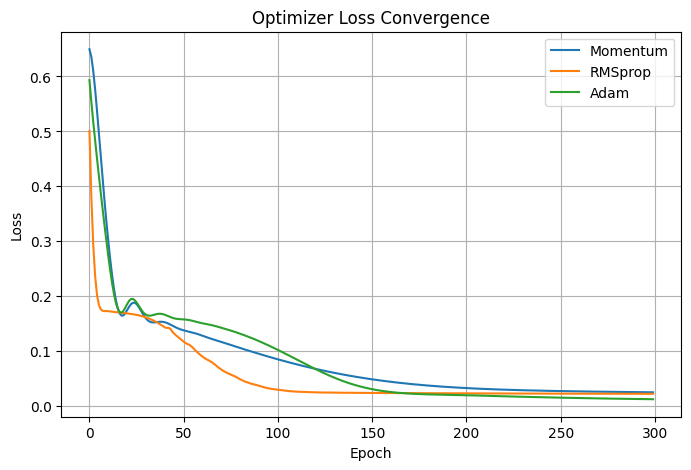


Optimizer Comparison Completed


In [1]:
# ==========================================================
# TASK 4
# Custom Gradient Descent Optimizers
# Momentum, RMSprop and Adam
# ==========================================================

# ----------------------------------------------------------
# Step 1 - Import Libraries
# ----------------------------------------------------------

import torch
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")


# ----------------------------------------------------------
# Step 2 - Create Non-Linear Dataset
# ----------------------------------------------------------

torch.manual_seed(42)

X = torch.linspace(-3, 3, 200).reshape(-1, 1)

y = torch.sin(X) + 0.1 * torch.randn(X.shape)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


# ----------------------------------------------------------
# Step 3 - Create Neural Network
# ----------------------------------------------------------

class SimpleModel:

    def __init__(self):

        self.W1 = torch.randn(1, 16) * 0.1
        self.b1 = torch.zeros(1, 16)

        self.W2 = torch.randn(16, 1) * 0.1
        self.b2 = torch.zeros(1, 1)

        self.W1.requires_grad = True
        self.b1.requires_grad = True
        self.W2.requires_grad = True
        self.b2.requires_grad = True


    def forward(self, x):

        hidden = torch.tanh(
            x @ self.W1 + self.b1
        )

        output = (
            hidden @ self.W2 + self.b2
        )

        return output


# ----------------------------------------------------------
# Step 4 - Loss Function
# ----------------------------------------------------------

def calculate_loss(prediction, target):

    return torch.mean(
        (prediction - target) ** 2
    )


# ----------------------------------------------------------
# Step 5 - Momentum Optimizer
# ----------------------------------------------------------

def momentum_update(parameters, velocities, learning_rate, momentum):

    for i in range(len(parameters)):

        velocities[i] = (
            momentum * velocities[i]
            + parameters[i].grad
        )

        parameters[i].data -= (
            learning_rate * velocities[i]
        )


# ----------------------------------------------------------
# Step 6 - RMSprop Optimizer
# ----------------------------------------------------------

def rmsprop_update(
    parameters,
    squared_values,
    learning_rate,
    decay
):

    for i in range(len(parameters)):

        squared_values[i] = (
            decay * squared_values[i]
            + (1 - decay) * parameters[i].grad ** 2
        )

        parameters[i].data -= (
            learning_rate *
            parameters[i].grad /
            (torch.sqrt(squared_values[i]) + 1e-8)
        )


# ----------------------------------------------------------
# Step 7 - Adam Optimizer
# ----------------------------------------------------------

def adam_update(
    parameters,
    first_moment,
    second_moment,
    learning_rate,
    beta1,
    beta2,
    step
):

    for i in range(len(parameters)):

        first_moment[i] = (
            beta1 * first_moment[i]
            + (1 - beta1) * parameters[i].grad
        )

        second_moment[i] = (
            beta2 * second_moment[i]
            + (1 - beta2) *
            parameters[i].grad ** 2
        )

        # Bias correction
        m_corrected = (
            first_moment[i] /
            (1 - beta1 ** step)
        )

        v_corrected = (
            second_moment[i] /
            (1 - beta2 ** step)
        )

        parameters[i].data -= (
            learning_rate *
            m_corrected /
            (torch.sqrt(v_corrected) + 1e-8)
        )


# ----------------------------------------------------------
# Step 8 - Training Function
# ----------------------------------------------------------

def train_model(method):

    model = SimpleModel()

    parameters = [
        model.W1,
        model.b1,
        model.W2,
        model.b2
    ]

    losses = []

    # Momentum values
    velocities = [
        torch.zeros_like(p)
        for p in parameters
    ]

    # RMSprop values
    squared_values = [
        torch.zeros_like(p)
        for p in parameters
    ]

    # Adam values
    first_moment = [
        torch.zeros_like(p)
        for p in parameters
    ]

    second_moment = [
        torch.zeros_like(p)
        for p in parameters
    ]

    epochs = 300

    for epoch in range(1, epochs + 1):

        # Forward pass
        prediction = model.forward(X)

        # Calculate loss
        loss = calculate_loss(
            prediction,
            y
        )

        losses.append(
            loss.item()
        )

        # Backward pass
        loss.backward()

        # Select optimizer
        if method == "Momentum":

            momentum_update(
                parameters,
                velocities,
                learning_rate=0.01,
                momentum=0.9
            )

        elif method == "RMSprop":

            rmsprop_update(
                parameters,
                squared_values,
                learning_rate=0.01,
                decay=0.9
            )

        elif method == "Adam":

            adam_update(
                parameters,
                first_moment,
                second_moment,
                learning_rate=0.01,
                beta1=0.9,
                beta2=0.999,
                step=epoch
            )

        # Clear gradients
        for parameter in parameters:

            parameter.grad.zero_()

    return losses


# ----------------------------------------------------------
# Step 9 - Train Using Different Optimizers
# ----------------------------------------------------------

momentum_loss = train_model("Momentum")

rmsprop_loss = train_model("RMSprop")

adam_loss = train_model("Adam")


# ----------------------------------------------------------
# Step 10 - Display Final Loss
# ----------------------------------------------------------

print("\nFinal Loss Values")

print(
    "Momentum :",
    round(momentum_loss[-1], 6)
)

print(
    "RMSprop  :",
    round(rmsprop_loss[-1], 6)
)

print(
    "Adam     :",
    round(adam_loss[-1], 6)
)


# ----------------------------------------------------------
# Step 11 - Plot Loss Convergence
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    momentum_loss,
    label="Momentum"
)

plt.plot(
    rmsprop_loss,
    label="RMSprop"
)

plt.plot(
    adam_loss,
    label="Adam"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Optimizer Loss Convergence")

plt.legend()

plt.grid()

plt.show()


# ----------------------------------------------------------
# Step 12 - Experiment Completed
# ----------------------------------------------------------

print("\nOptimizer Comparison Completed")